### neurons

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

### simple neuron network

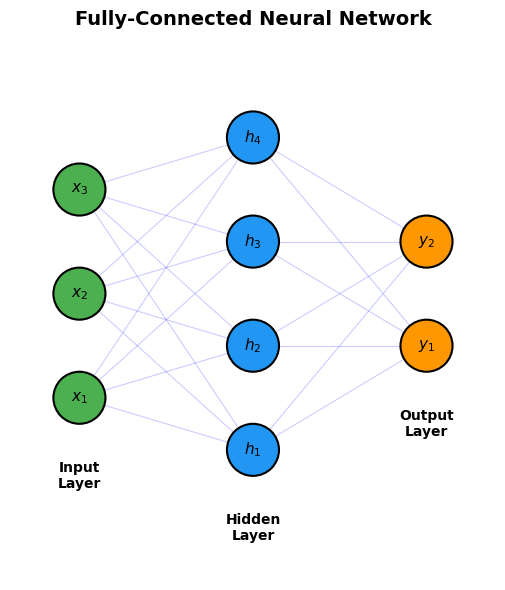

In [2]:
def draw_neural_network(layer_sizes, ax=None):
    """
    Draw a fully-connected neural network diagram.
    
    Parameters
    ----------
    layer_sizes : list of int
        Number of neurons in each layer, e.g. [3, 4, 2].
    ax : matplotlib Axes, optional
        Axes to draw on. If None, creates a new figure.
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    n_layers = len(layer_sizes)
    max_neurons = max(layer_sizes)
    
    # Spacing
    h_spacing = 2.0  # horizontal spacing between layers
    v_spacing = 1.2  # vertical spacing between neurons
    radius = 0.3
    
    # Compute positions for each neuron
    positions = []  # positions[layer][neuron] = (x, y)
    for i, size in enumerate(layer_sizes):
        layer_positions = []
        x = i * h_spacing
        y_start = (max_neurons - size) * v_spacing / 2  # center vertically
        for j in range(size):
            y = y_start + j * v_spacing
            layer_positions.append((x, y))
        positions.append(layer_positions)
    
    # Draw connections (edges) between consecutive layers
    for i in range(n_layers - 1):
        for (x1, y1) in positions[i]:
            for (x2, y2) in positions[i + 1]:
                ax.plot([x1, x2], [y1, y2], 'b-', alpha=0.2, linewidth=0.8)
    
    # Draw neurons (circles)
    layer_labels = ['Input\nLayer', 'Hidden\nLayer', 'Output\nLayer']
    if n_layers > 3:
        layer_labels = ['Input'] + [f'Hidden {i}' for i in range(1, n_layers - 1)] + ['Output']
    
    colors = ['#4CAF50', '#2196F3', '#FF9800']  # green, blue, orange
    if n_layers > 3:
        colors = ['#4CAF50'] + ['#2196F3'] * (n_layers - 2) + ['#FF9800']
    
    for i, layer_pos in enumerate(positions):
        color = colors[min(i, len(colors) - 1)]
        for j, (x, y) in enumerate(layer_pos):
            circle = plt.Circle((x, y), radius, color=color, ec='black',
                                linewidth=1.5, zorder=4)
            ax.add_patch(circle)
            # Label neuron
            if i == 0:
                ax.text(x, y, f'$x_{j+1}$', ha='center', va='center',
                        fontsize=11, fontweight='bold', zorder=5)
            elif i == n_layers - 1:
                ax.text(x, y, f'$y_{j+1}$', ha='center', va='center',
                        fontsize=11, fontweight='bold', zorder=5)
            else:
                ax.text(x, y, f'$h_{j+1}$', ha='center', va='center',
                        fontsize=11, fontweight='bold', zorder=5)
        
        # Layer label below
        x_center = positions[i][0][0]
        y_bottom = min(p[1] for p in positions[i]) - 0.9
        label = layer_labels[min(i, len(layer_labels) - 1)]
        ax.text(x_center, y_bottom, label, ha='center', va='center',
                fontsize=10, fontweight='bold')
    
    ax.set_xlim(-0.8, (n_layers - 1) * h_spacing + 0.8)
    ax.set_ylim(-1.5, max_neurons * v_spacing)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Fully-Connected Neural Network', fontsize=14, fontweight='bold')
    
    return ax


fig, ax = plt.subplots(1, 1, figsize=(10, 6))
draw_neural_network([3, 4, 2], ax=ax)
plt.tight_layout()
plt.show()
     

### Coding a single neuron

In [3]:
def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))

def singlen(w,x,b,activation_fn=sigmoid):
    z=np.dot(w,x)+b
    a=activation_fn(z)
    return a,z

np.random.seed(42)
x=np.array([0.5,-0.8,-0.9])
w=np.random.randn(3)
b=np.random.randn()

a, z=singlen(w,x,b)

print(f"input x: {x}")
print(f"bias b: {b}")
print(f"weight w: {w}")
print(f"combined weight: {z}")
print(f"Output :{a}")

z_manual = w[0]*x[0] + w[1]*x[1] + w[2]*x[2] + b
a_manual = 1.0 / (1.0 + np.exp(-z_manual))
print(f"wieghted value is close: {np.isclose(z,z_manual)}") 
print(f"output value is close: {np.isclose(a,a_manual)}") 

input x: [ 0.5 -0.8 -0.9]
bias b: 1.5230298564080254
weight w: [ 0.49671415 -0.1382643   0.64768854]
combined weight: 1.2990786895599662
Output :0.7856798871717721
wieghted value is close: True
output value is close: True


### layers of neuron

In [4]:
def neuronlayer(w,x,b,activation_fn=sigmoid):
    z=w @ x+b
    a=activation_fn(z)
    return a,z

np.random.seed(42)
inputs=5
neurons=7

x=np.array([0.8,-0.7,1.4,2.7,-1.0])
w=np.random.randn(neurons,inputs)
b=np.random.randn(neurons)

a,z=neuronlayer(w,x,b)

print(f"shape of \n weights:{w.shape} \n inputs:{x.shape} \n bias:{b.shape} \n preactivation weigth:{z.shape} \n output:{a.shape}")

print(f"pre-activation weight :{z}")
print(f"output:{a}")

shape of 
 weights:(7, 5) 
 inputs:(5,) 
 bias:(7,) 
 preactivation weigth:(7,) 
 output:(7,)
pre-activation weight :[ 4.52641062 -1.81962721 -5.1065851  -1.66844932 -1.68047423  0.82884667
 -5.30385227]
output:[0.98929637 0.13947861 0.00602027 0.15863103 0.15703268 0.69611101
 0.0049478 ]


In [5]:
#verification
for i in range(neurons):
    aone,zone=singlen(w[i],x,b[i])
    print(f"{zone:.4f} and {aone:.4f} | {z[i]:.4f} and {a[i]:.4f}")

4.5264 and 0.9893 | 4.5264 and 0.9893
-1.8196 and 0.1395 | -1.8196 and 0.1395
-5.1066 and 0.0060 | -5.1066 and 0.0060
-1.6684 and 0.1586 | -1.6684 and 0.1586
-1.6805 and 0.1570 | -1.6805 and 0.1570
0.8288 and 0.6961 | 0.8288 and 0.6961
-5.3039 and 0.0049 | -5.3039 and 0.0049


### different activation function implementation

In [6]:
def Relu(z):
    return np.maximum(0,z)

def tanh(z):
    return np.tanh(z)

a,z=neuronlayer(w,x,b,Relu)
print("for Relu")
print(f"pre-activation weight :{z}")
print(f"output:{a}")
a,z=neuronlayer(w,x,b,tanh)
print("for tanh")
print(f"pre-a   ctivation weight :{z}")
print(f"output:{a}")

for Relu
pre-activation weight :[ 4.52641062 -1.81962721 -5.1065851  -1.66844932 -1.68047423  0.82884667
 -5.30385227]
output:[4.52641062 0.         0.         0.         0.         0.82884667
 0.        ]
for tanh
pre-a   ctivation weight :[ 4.52641062 -1.81962721 -5.1065851  -1.66844932 -1.68047423  0.82884667
 -5.30385227]
output:[ 0.99976591 -0.94880124 -0.99992663 -0.93134637 -0.93292307  0.67985624
 -0.99995055]


### forward Propogation

In [9]:
def sigmoid_derivative(z):
    s=sigmoid(z)
    return s*(1-s)

testz=np.array([1.0,2.0,3.0])
sigmoid_derivative(testz)

array([0.19661193, 0.10499359, 0.04517666])